In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [95]:
u = np.array([60, 50, 40, 30, 20])
v_convex = np.array([12.7, 13.4, 12.1, 15.3, 21.6]) 
v_concave = np.array([17.2, 18.4, 20.2, 25.9, 48.7]) 

invu = 1/u
invv_convex = 1/v_convex
invv_concave = 1/v_concave

print("1/u", invu)
print("1/convex", invv_convex)
print("1/combined", invv_concave)

f_convex = invu + invv_convex
f_concave = invu + invv_concave


print("\n",1/f_concave, 1/f_convex)

avgf_convex = np.average(1/f_convex)
print(avgf_convex)
avgf_concave = np.average(1/f_concave)
print(avgf_concave)

f_cconc = - f_convex + f_concave
print("\n",f_cconc)
print("\n",1/f_cconc, np.average(1/f_cconc), np.std(1/f_cconc))
print("\n",avgf_convex, np.std(1/f_convex))

1/u [0.01666667 0.02       0.025      0.03333333 0.05      ]
1/convex [0.07874016 0.07462687 0.08264463 0.06535948 0.0462963 ]
1/combined [0.05813953 0.05434783 0.04950495 0.03861004 0.02053388]

 [13.36787565 13.4502924  13.42192691 13.89982111 14.1775837 ] [10.48143054 10.56782334  9.28982726 10.13245033 10.38461538]
10.171229370263855
13.6634999523972

 [-0.02060062 -0.02027904 -0.03313968 -0.02674944 -0.02576242]

 [-48.54222222 -49.312      -30.17530864 -37.38396226 -38.81623616] -40.84594585814203 7.223216638844789

 10.171229370263855 0.4642022483112251


-1.0127148281261837
0.09890221494998122


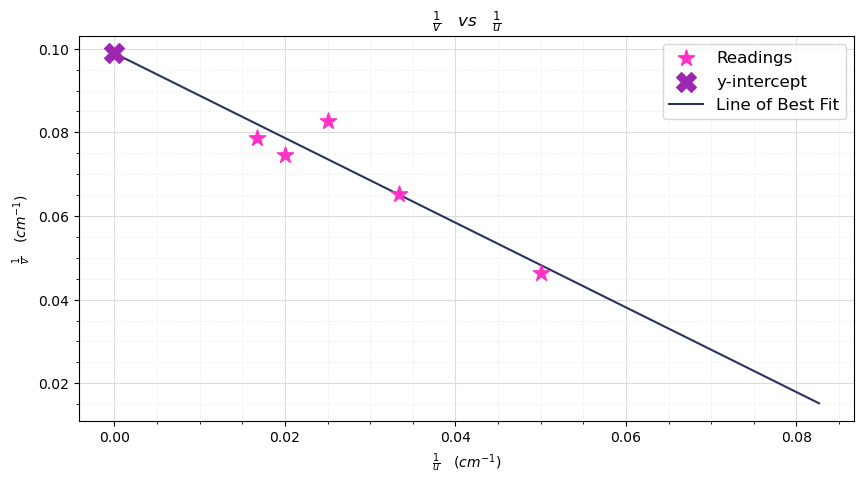

In [117]:
extended_y = np.linspace(0, max(invv_convex), 300)

slope, intercept = np.polyfit(invu, invv_convex, 1)

plt.figure(figsize=(10,5))

plt.ylabel(r"$\frac{1}{v} \quad (cm^{-1})$")
plt.xlabel(r"$\frac{1}{u} \quad (cm^{-1})$")

plt.scatter(invu,invv_convex, color="#ff30c4", s=150, marker="*",zorder=6, label="Readings")
plt.scatter(0, intercept, color="#9C27B0", s=200, marker="X", zorder=6, label="y-intercept")

plt.plot(
    extended_y,
    np.polyval([slope, intercept], extended_y),
    label="Line of Best Fit",
    color="#29335C",
    zorder=5
)

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.legend(fontsize="large")
plt.title(r"$\frac{1}{v} \quad vs \quad \frac{1}{u}$")

print(slope)
print(intercept)

plt.show()


In [91]:
x = np.array([0.0976, 0.09825])
print(np.std(x))

0.0003249999999999989


In [96]:
incidence = np.array([0, 20, 30,40,50,60,70,80])
perpendicular_mV = np.array([54.6,6.2,8.38,11.5,17.8,21.7,27.8,31.9])
parallel_mV = np.array([14,0.4,0.5,0.6,0.4,0.5,3.5,4])

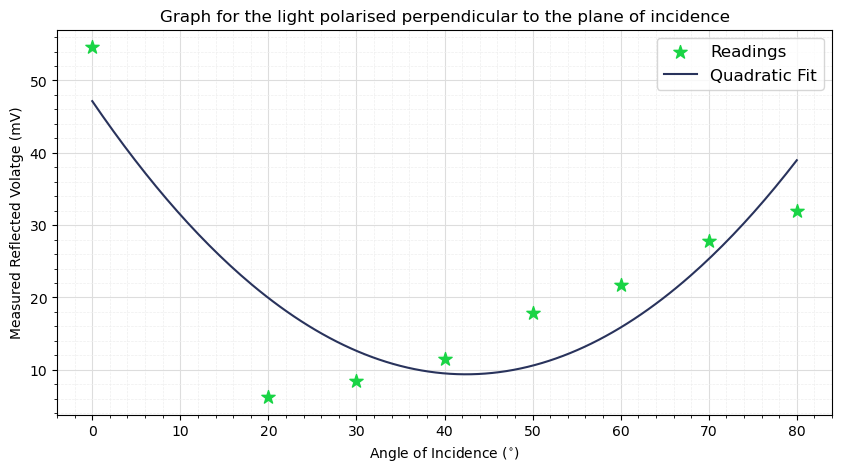

In [101]:
coeff_perp = np.polyfit(incidence, perpendicular_mV, 2)

inc_smooth = np.linspace(0,80,200)
perp_smooth = np.polyval(coeff_perp, inc_smooth)

plt.figure(figsize=(10,5))

plt.ylabel("Measured Reflected Volatge (mV)")
plt.xlabel(r"Angle of Incidence $(^{\circ})$")

plt.scatter(incidence,perpendicular_mV, color="#19d445", s=100, marker="*",zorder=6, label="Readings")

plt.plot(inc_smooth, perp_smooth, linestyle="-",color = "#29335C", zorder=5, label="Quadratic Fit")

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.title("Graph for the light polarised perpendicular to the plane of incidence")
plt.legend(fontsize="large")

plt.show()

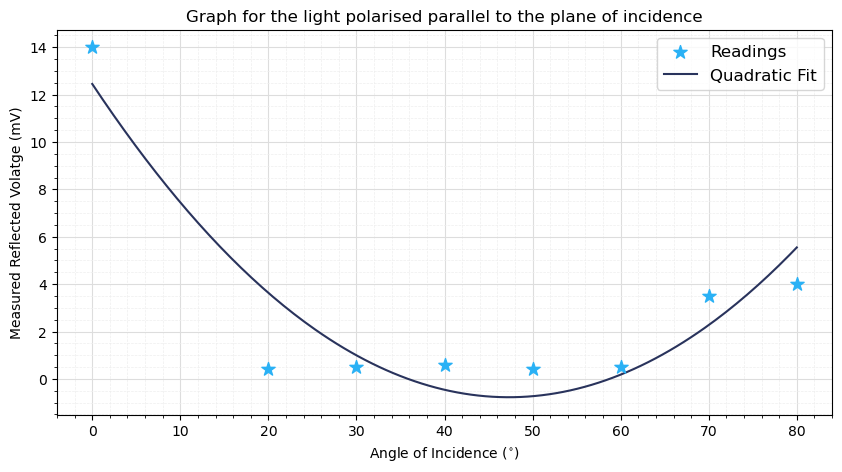

In [105]:
coeff_para = np.polyfit(incidence, parallel_mV, 2)

inc_smooth = np.linspace(0,80,200)
para_smooth = np.polyval(coeff_para, inc_smooth)

plt.figure(figsize=(10,5))

plt.ylabel("Measured Reflected Volatge (mV)")
plt.xlabel(r"Angle of Incidence $(^{\circ})$")

plt.scatter(incidence,parallel_mV, color="#2ab1f5", s=100, marker="*",zorder=6, label="Readings")

plt.plot(inc_smooth, para_smooth, linestyle="-",color = "#29335C", zorder=5, label="Quadratic Fit")

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.title("Graph for the light polarised parallel to the plane of incidence")
plt.legend(fontsize="large")

plt.show()

In [114]:
a, b, c = coeff_perp
xmin_perp = -b / (2 * a)
ymin_perp = np.polyval(coeff_perp, xmin_perp)

a_p, b_p, c_p = coeff_para
xmin_para = -b_p / (2 * a_p)
ymin_para = np.polyval(coeff_para, xmin_para)

print(f"perp min: x = {xmin_perp:.2f}, y = {ymin_perp:.2f}")
print(f"para min: x = {xmin_para:.2f}, y = {ymin_para:.2f}")

xmin_perp_rad = np.pi/(180) * xmin_perp
xmin_para_rad = np.pi/(180) * xmin_para

print("n perp:", np.tan(xmin_perp_rad)) 
print("n para:", np.tan(xmin_para_rad))

perp min: x = 42.44, y = 9.37
para min: x = 47.30, y = -0.77
n perp: 0.9142470910225726
n para: 1.0835405824710673
